In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.stats.api as sms
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("marketing_AB.csv")

# Removing Outliers

In [3]:
df.loc[(df.converted == True),  'converted2'] = 1
df.loc[(df.converted == False),  'converted2'] = 0
df["converted2"] = df["converted2"].astype(int)

In [4]:
def drop_outlier(df, col):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[[col]])
    plt.title(f'{col} Boxplot')
    plt.show()
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    down_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR
    
    df = df[~((df[col] < down_limit) | (df[col] > up_limit))]
    return df


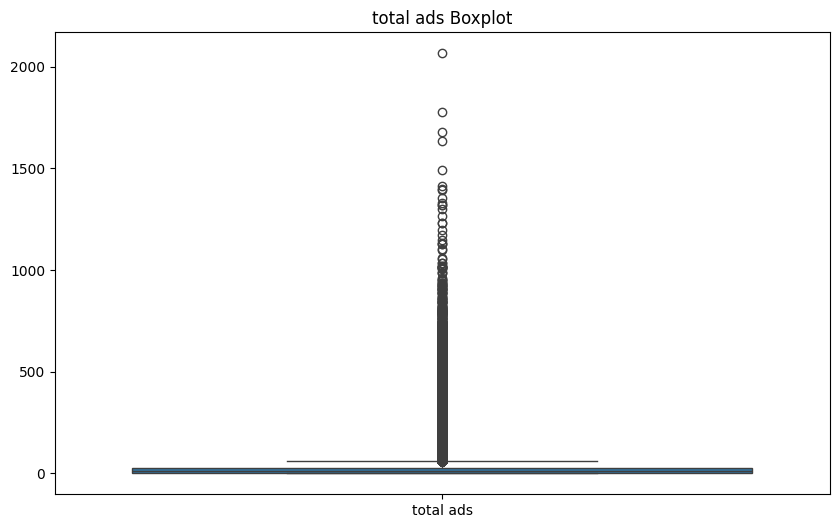

In [5]:
df = drop_outlier(df, 'total ads')

# Total Ads Viewed vs Purchase Status by Test Group

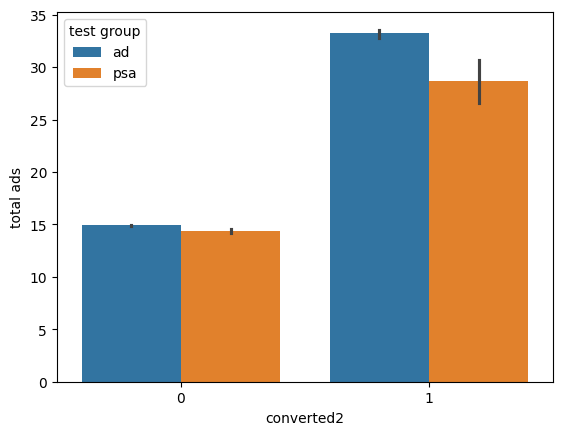

In [6]:
sns.barplot(df, x = 'converted2', y = 'total ads', hue = 'test group');

In [7]:
df_groupby = df.groupby(["test group","most ads day"]).agg({"total ads":"mean", "converted2":"sum"}).reset_index()
df_groupby.head()

,test group,most ads day,total ads,converted2
0,ad,Friday,15.255024,958
1,ad,Monday,14.825415,1324
2,ad,Saturday,15.944834,777
3,ad,Sunday,15.679764,987
4,ad,Thursday,14.510822,835


# Relationship between Purchase Status, Total Ads Viewed, and Most Ads Day by Test Group

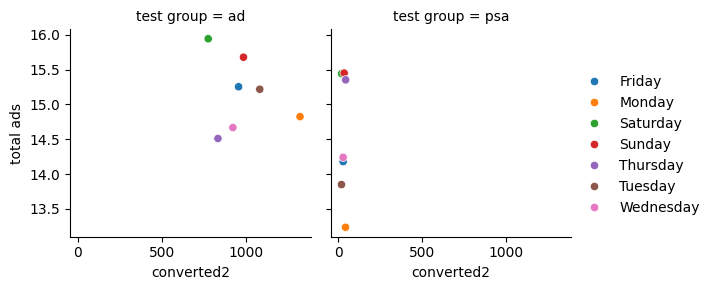

In [8]:
g = sns.FacetGrid(df_groupby, col="test group")
g.map(sns.scatterplot, 'converted2', 'total ads', 'most ads day')
g.add_legend()
plt.show()

# Kernel Density Estimation of Total Ads Viewed by Most Ads Day

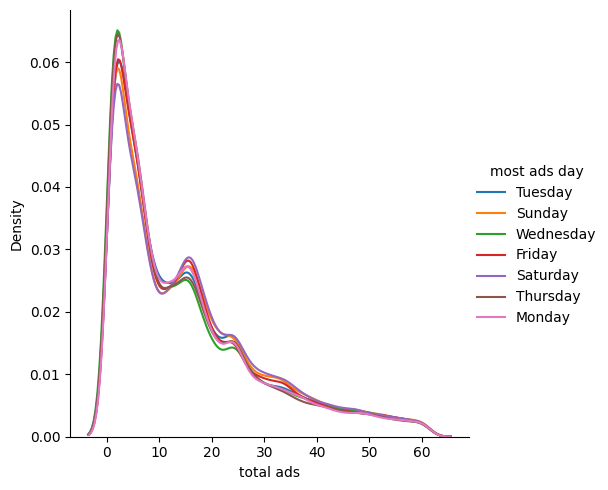

In [9]:
(sns
 .FacetGrid(df,
              hue = "most ads day",
              height = 5
           )
 .map(sns.kdeplot, "total ads", shade= False)
 .add_legend()
);

# Kernel Density Estimation of Total Ads Viewed by Test Group

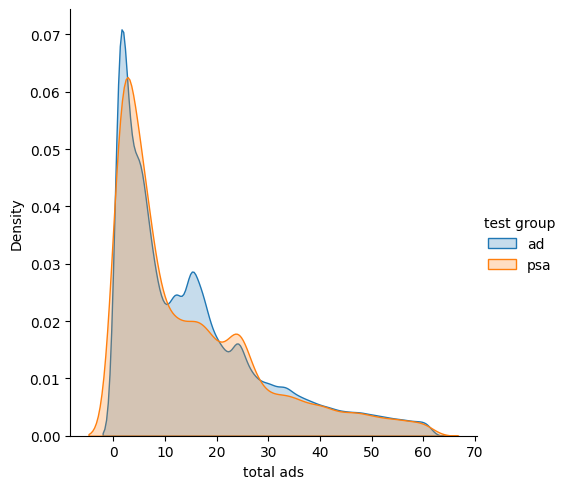

In [10]:
(sns
 .FacetGrid(df,
              hue = "test group",
              height = 5
           )
 .map(sns.kdeplot, "total ads", shade= True)
 .add_legend()
);

# Total Ads Viewed by Most Ads Day and Test Group

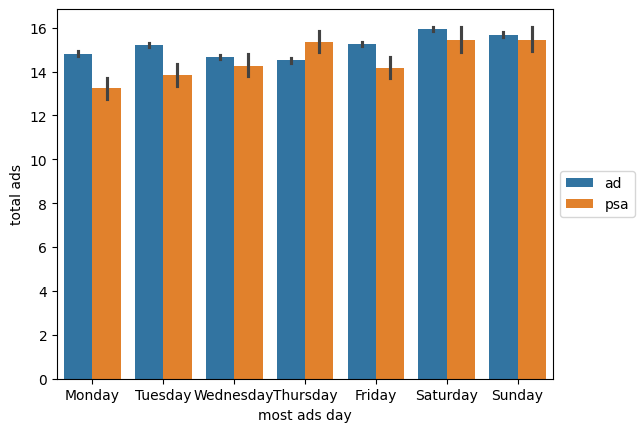

In [11]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.barplot(data=df, x='most ads day', y='total ads', hue='test group', order=days_order)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

# Total Ads Viewed by Most Ads Hour and Test Group

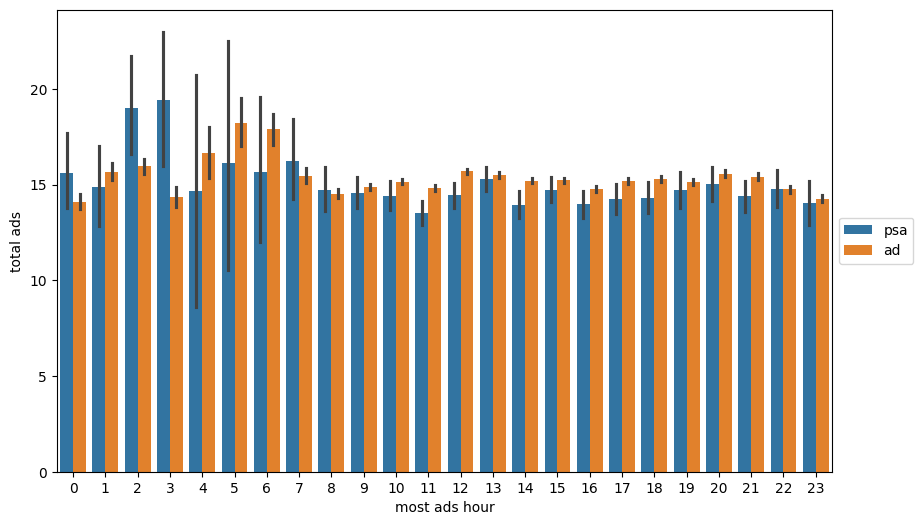

In [12]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='most ads hour', y='total ads', hue='test group')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()


In [13]:
def compare_groups_test(df, group_col, test_value, control_value, target_col):
    
    # H0: M1 = M2
    # H1: M1 != M2
    # REJECT H0 if p-value < 0.05.
    # CANNOT REJECT H0 if p-value > 0.05.
    
    # Assumption of Normality
    print("-"*150)
    print("Assumption Check Step 1")
    print("  - Normality Assumption (Shapiro Test)")
    test_stat_test, pvalue_test = shapiro(df.loc[df[group_col] == test_value, target_col])
    test_stat_control, pvalue_test_control = shapiro(df.loc[df[group_col] == control_value, target_col])
    
    if pvalue_test_control > 0.05 or pvalue_test > 0.05:
        print("\n       * Normality assumption is satisfied.")
        print('\n       * Test Group Stat = %.4f, p-value = %.4f' % (test_stat_test, pvalue_test))
        print('\n       * Test Stat Control = %.4f, p-value = %.4f' % (test_stat_control, pvalue_test_control))
        shapiro_test_h0_rejection = 0
    
    else:
        print("\n       * Normality assumption is not satisfied.")
        print('\n       * Test Group Stat = %.4f, p-value = %.4f' % (test_stat_test, pvalue_test))
        print('\n       * Test Stat Control = %.4f, p-value = %.4f' % (test_stat_control, pvalue_test_control))
        shapiro_test_h0_rejection = 1
        
    # Homogeneity of Variances
    print("-"*150)
    print("Assumption Check Step 2")
    print("  - Homogeneity of Variances (Levene Test)")
    
    test_stat, pvalue = levene(df.loc[df[group_col] == test_value, target_col], df.loc[df[group_col] == control_value, target_col])
    
    if pvalue > 0.05:
        levene_test_h0_rejection = 0
        print("\n       * Variances are homogeneous.")
        print('\n       * Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
    else:
        levene_test_h0_rejection = 1
        print("\n       * Variances are not homogeneous.")
        test_stat, pvalue = levene(df.loc[df[group_col] == test_value, target_col], df.loc[df[group_col] == control_value, target_col])
        print('\n       * Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
        
    
    # If Assumptions are Met, Apply T Test (Parametric Test)
    
    if shapiro_test_h0_rejection == 0 and levene_test_h0_rejection == 0:
        print("-"*150)
        print("If Assumptions are Met, Apply T Test (Parametric Test)")
        
        test_stat, pvalue = ttest_ind(df.loc[df[group_col] == test_value, target_col],
                              df.loc[df[group_col] == control_value, target_col],
                              equal_var=True)
        if pvalue > 0.05:
            print("Cannot Reject H0")
            print('T Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
        else:
            print("Reject H0")
            print('T Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
        
    elif shapiro_test_h0_rejection == 0 and levene_test_h0_rejection == 1:
        print("-"*150)
        print("If Assumptions are Met, Apply T Test (Parametric Test)")
        
        test_stat, pvalue = ttest_ind(df.loc[df[group_col] == test_value, target_col],
                              df.loc[df[group_col] == control_value, target_col],
                              equal_var=False)
        if pvalue > 0.05:
            print("Cannot Reject H0")
            print('T Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
        else:
            print("Reject H0")
            print('T Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
        
    
    # If Assumptions are Not Met, Apply Mann-Whitney U Test (Non-Parametric Test)
    
    else:
        print("-"*150)
        print("If Assumptions are Not Met, Apply Mann-Whitney U Test (Non-Parametric Test)")
        test_stat, pvalue = mannwhitneyu(df.loc[df[group_col] == test_value, target_col],
                                 df.loc[df[group_col] == control_value, target_col])
    
        if pvalue > 0.05:
            print("\n  * Cannot Reject H0")
            print('\n  * T Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))
        else:
            print("\n  * Reject H0")
            print('\n  * T Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))


In [14]:
compare_groups_test(df,"converted", 0, 1, "total ads")

------------------------------------------------------------------------------------------------------------------------------------------------------
Assumption Check Step 1
  - Normality Assumption (Shapiro Test)

       * Normality assumption is not satisfied.

       * Test Group Stat = 0.8636, p-value = 0.0000

       * Test Stat Control = 0.9600, p-value = 0.0000
------------------------------------------------------------------------------------------------------------------------------------------------------
Assumption Check Step 2
  - Homogeneity of Variances (Levene Test)

       * Variances are not homogeneous.

       * Test Stat = 1212.0188, p-value = 0.0000
------------------------------------------------------------------------------------------------------------------------------------------------------
If Assumptions are Not Met, Apply Mann-Whitney U Test (Non-Parametric Test)

  * Reject H0

  * T Test Stat = 769331746.5000, p-value = 0.0000


In [15]:
def add_weekday_weekend_column(df, day_column, new_column_name):
    weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    weekends = ['Saturday', 'Sunday']
    
    # Yeni sütunu oluşturma ve her güne göre etiketleme
    df[new_column_name] = df[day_column].apply(lambda x: 'weekdays' if x in weekdays else 'weekends' if x in weekends else 'Other')
    
    return df


df = add_weekday_weekend_column(df, 'most ads day', 'weekdays_weekends')

In [16]:
compare_groups_test(df,"weekdays_weekends", "weekdays", "weekends", "total ads")

------------------------------------------------------------------------------------------------------------------------------------------------------
Assumption Check Step 1
  - Normality Assumption (Shapiro Test)

       * Normality assumption is not satisfied.

       * Test Group Stat = 0.8587, p-value = 0.0000

       * Test Stat Control = 0.8783, p-value = 0.0000
------------------------------------------------------------------------------------------------------------------------------------------------------
Assumption Check Step 2
  - Homogeneity of Variances (Levene Test)

       * Variances are not homogeneous.

       * Test Stat = 199.2477, p-value = 0.0000
------------------------------------------------------------------------------------------------------------------------------------------------------
If Assumptions are Not Met, Apply Mann-Whitney U Test (Non-Parametric Test)

  * Reject H0

  * T Test Stat = 28083790182.0000, p-value = 0.0000


In [17]:
compare_groups_test(df,"test group", "ad", "psa", "total ads")

------------------------------------------------------------------------------------------------------------------------------------------------------
Assumption Check Step 1
  - Normality Assumption (Shapiro Test)

       * Normality assumption is not satisfied.

       * Test Group Stat = 0.8651, p-value = 0.0000

       * Test Stat Control = 0.8476, p-value = 0.0000
------------------------------------------------------------------------------------------------------------------------------------------------------
Assumption Check Step 2
  - Homogeneity of Variances (Levene Test)

       * Variances are homogeneous.

       * Test Stat = 0.1915, p-value = 0.6617
------------------------------------------------------------------------------------------------------------------------------------------------------
If Assumptions are Not Met, Apply Mann-Whitney U Test (Non-Parametric Test)

  * Reject H0

  * T Test Stat = 5691411788.0000, p-value = 0.0000
